# OMNI Solar Wind Parameters EDA

This notebook explores the `juliensimon/omni-solar-wind-parameters` datasetm for the geomagnetic storm prediction project.

The goal of this EDA is to determine whether this dataset can support out project question: predicting whether a geomagnetic storm will occur, or predicting storm intensity, using solar activity and solar wind features.

Compared with the initial real-time Solar Wind dataset, this OMNI dataset has a much longer time range and includes both solar wind/IMF variables and geomagnetic response indices in one hourly time series. Because it contains possible predictors and possible target variables together, this EDA will focus on separating input features from target candidates and checking data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%pip install datasets -q
from datasets import load_dataset


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
ds = load_dataset("juliensimon/omni-solar-wind-parameters", split="train")
df = ds.to_pandas()

df.head()

,datetime,bartels_rotation_number,b_magnitude_avg_nt,b_magnitude_vector_nt,b_lat_angle_gse_deg,b_lon_angle_gse_deg,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,...,proton_flux_gt4mev,proton_flux_gt10mev,proton_flux_gt30mev,proton_flux_gt60mev,ap_index_nt,f107_index_sfu,pc_n_index,al_index_nt,au_index_nt,magnetosonic_mach_number
0,1963-01-01 00:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
1,1963-01-01 01:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
2,1963-01-01 02:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
3,1963-01-01 03:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN
4,1963-01-01 04:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN


### Initial Head Observation

**Key takeaways**
- Early rows: many missing solar wind / IMF values
- Geomagnetic indices: available earlier than many predictor variables
- Missingness pattern: likely differs by variable group and time period

**EDA decision**
- Check coverage before choosing features
- Use observed rows only, not future placeholder rows
- Separate predictors vs target candidates early
- Watch for target leakage

In [4]:
df.shape

(561024, 48)

### Dataset Size

- Rows: 561,024 hourly records
- Columns: 48 variables
- This dataset is much larger and longer than the real-time solar wind dataset.
- Main EDA focus: variable coverage, target candidates, and usable feature groups.

In [5]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "non_missing_count": df.notna().sum().values,
    "unique_count": df.nunique().values
})

column_summary

,column,dtype,missing_count,missing_percent,non_missing_count,unique_count
0,datetime,datetime64[us],0,0.00,561024,561024
1,bartels_rotation_number,float64,4920,0.88,556104,859
2,b_magnitude_avg_nt,float64,129103,23.01,431921,453
3,b_magnitude_vector_nt,float64,129103,23.01,431921,446
4,b_lat_angle_gse_deg,float64,129103,23.01,431921,1790
5,b_lon_angle_gse_deg,float64,129103,23.01,431921,3602
6,bx_gse_nt,float64,129103,23.01,431921,498
7,by_gse_nt,float64,129103,23.01,431921,607
8,bz_gse_nt,float64,129103,23.01,431921,588
9,by_gsm_nt,float64,129129,23.02,431895,591


In [6]:
measurement_cols = [col for col in df.columns if col != "datetime"]

df["has_any_measurement"] = df[measurement_cols].notna().any(axis=1)

df.loc[df["has_any_measurement"], "datetime"].min(), df.loc[df["has_any_measurement"], "datetime"].max()

(Timestamp('1963-01-01 00:00:00'), Timestamp('2026-06-10 11:00:00'))

In [7]:
df["has_any_measurement"].value_counts()

has_any_measurement
True     556116
False      4908
Name: count, dtype: int64

In [8]:
df_observed = df[df["has_any_measurement"]].copy()

df_observed.shape

(556116, 49)

### Future Placeholder Rows Check

**What we see**
- The full dataset has timestamps through 2026-12-31, but actual measurements are available through 2026-06-10 11:00:00.
- 4908 rows have `datetime` only and no other measurement values. 
- `df_observed` keeps only rows with at least one non-datetime measruement. 

**Decision**
- Use `df_observed` for missingness summaries, visualizations, and modeling feasibility checks.

In [9]:
observed_column_summary = pd.DataFrame({
    "column": df_observed.drop(columns=["has_any_measurement"]).columns,
    "dtype": df_observed.drop(columns=["has_any_measurement"]).dtypes.astype(str).values,
    "missing_count": df_observed.drop(columns=["has_any_measurement"]).isna().sum().values,
    "missing_percent": (df_observed.drop(columns=["has_any_measurement"]).isna().mean() * 100).round(2).values,
    "non_missing_count": df_observed.drop(columns=["has_any_measurement"]).notna().sum().values,
    "unique_count": df_observed.drop(columns=["has_any_measurement"]).nunique().values
})

observed_column_summary

,column,dtype,missing_count,missing_percent,non_missing_count,unique_count
0,datetime,datetime64[us],0,0.00,556116,556116
1,bartels_rotation_number,float64,12,0.00,556104,859
2,b_magnitude_avg_nt,float64,124195,22.33,431921,453
3,b_magnitude_vector_nt,float64,124195,22.33,431921,446
4,b_lat_angle_gse_deg,float64,124195,22.33,431921,1790
5,b_lon_angle_gse_deg,float64,124195,22.33,431921,3602
6,bx_gse_nt,float64,124195,22.33,431921,498
7,by_gse_nt,float64,124195,22.33,431921,607
8,bz_gse_nt,float64,124195,22.33,431921,588
9,by_gsm_nt,float64,124221,22.34,431895,591


### Observed Column Coverage

**Key takeaways**
- Target candidates: almost complete  
  - `dst_index_nt`, `kp_index`, `ap_index_nt`
- Key IMF variables: ~22% missing  
  - example: `bz_gsm_nt`
- Key solar wind variables: ~23–26% missing  
  - `flow_speed_kms`, `proton_density_cm3`, `flow_pressure_npa`
- Energetic proton flux variables: much higher missingness

**EDA decision**
- Use `df_observed` for EDA
- Do not use all observed rows automatically for modeling
- Build a smaller modeling dataset after choosing:
  - target variable
  - selected input features
  - acceptable missingness threshold

In [10]:
imf_cols = [
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt"
]

solar_wind_cols = [
    "proton_temperature_k",
    "proton_density_cm3",
    "flow_speed_kms",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]

target_candidate_cols = [
    "kp_index",
    "dst_index_nt",
    "ap_index_nt",
    "ae_index_nt",
    "al_index_nt",
    "au_index_nt"
]

solar_context_cols = [
    "sunspot_number",
    "f107_index_sfu"
]

particle_cols = [
    "proton_flux_gt1mev",
    "proton_flux_gt2mev",
    "proton_flux_gt4mev",
    "proton_flux_gt10mev",
    "proton_flux_gt30mev",
    "proton_flux_gt60mev"
]

In [11]:
groups = {
    "IMF / magnetic field": imf_cols,
    "Solar wind plasma / derived": solar_wind_cols,
    "Target candidates / geomagnetic indices": target_candidate_cols,
    "Solar context": solar_context_cols,
    "Energetic particles": particle_cols
}

group_summary = []

for group_name, cols in groups.items():
    group_missing = df_observed[cols].isna().mean().mean() * 100
    group_complete_rows = df_observed[cols].notna().all(axis=1).mean() * 100
    
    group_summary.append({
        "group": group_name,
        "num_columns": len(cols),
        "avg_missing_percent": round(group_missing, 2),
        "complete_rows_percent": round(group_complete_rows, 2)
    })

pd.DataFrame(group_summary)

,group,num_columns,avg_missing_percent,complete_rows_percent
0,IMF / magnetic field,7,22.33,77.66
1,Solar wind plasma / derived,8,28.04,68.12
2,Target candidates / geomagnetic indices,6,4.32,89.78
3,Solar context,2,0.07,99.87
4,Energetic particles,6,48.35,35.47


### Variable Group Coverage

**Key takeaways**
- Best coverage: solar context variables
- Mostly complete: target candidates / geomagnetic indices
- Usable coverage:
  - IMF / magnetic field: 77.66% complete rows
  - Solar wind plasma / derived: 68.12% complete rows
- Lower priority for first model:
  - Energetic particle variables
  - Reason: high missingness

**EDA decision**
- Prioritize IMF, solar wind, and target candidate variables
- Treat energetic particle variables as optional for later analysis
- Build final modeling dataset after choosing:
  - target variable
  - selected input features
  - missingness threshold

**Note**
- Derived variables are calculated from measured solar wind / IMF variables.
- They may be useful domain features, but can overlap with raw variables.

## Priority Column Dictionary

| Column | Group | Plain-English meaning | Modeling role |
|---|---|---|---|
| `datetime` | Time | Hourly timestamp for each observation | Needed for time-based analysis and merging |
| `bz_gsm_nt` | IMF / magnetic field | North-south magnetic field component in GSM coordinates; negative means southward Bz | Key input candidate |
| `by_gsm_nt` | IMF / magnetic field | East-west magnetic field component in GSM coordinates | Input candidate |
| `b_magnitude_avg_nt` | IMF / magnetic field | Average total interplanetary magnetic field strength during the hour | Input candidate |
| `flow_speed_kms` | Solar wind plasma | Solar wind speed in km/s | Key input candidate |
| `proton_density_cm3` | Solar wind plasma | Solar wind proton density | Input candidate |
| `proton_temperature_k` | Solar wind plasma | Solar wind proton temperature | Input candidate |
| `flow_pressure_npa` | Derived solar wind | Solar wind dynamic pressure | Input candidate |
| `electric_field_mvpm` | Derived solar wind | Interplanetary electric field related to solar wind speed and Bz | Strong input candidate; check leakage/derivation |
| `plasma_beta` | Derived solar wind | Ratio of plasma pressure to magnetic pressure | Optional input candidate |
| `kp_index` | Geomagnetic index | Planetary geomagnetic activity index; stored as Kp × 10 | Target candidate |
| `dst_index_nt` | Geomagnetic index | Storm-time disturbance index; more negative values indicate stronger storms | Target candidate |
| `ap_index_nt` | Geomagnetic index | Linear version of Kp-style geomagnetic activity | Target candidate |
| `ae_index_nt` | Geomagnetic index | Auroral electrojet activity index | Secondary target/context candidate |
| `sunspot_number` | Solar context | Proxy for solar cycle activity | Context feature candidate |
| `f107_index_sfu` | Solar context | Solar 10.7 cm radio flux; proxy for solar activity/EUV output | Context feature candidate |

## Time Range and Cadence Check

This dataset is expected to be hourly. We check the observed time range and the gaps between consecutive timestamps.

In [12]:
df_observed = df_observed.sort_values("datetime").copy()
df_observed["time_diff"] = df_observed["datetime"].diff()
df_observed["datetime"].min(), df_observed["datetime"].max()

(Timestamp('1963-01-01 00:00:00'), Timestamp('2026-06-10 11:00:00'))

In [13]:
df_observed["time_diff"].value_counts().head(10)

time_diff
0 days 01:00:00    556115
Name: count, dtype: int64

### Time Range and Cadence Observation

**Key takeaways**
- Observed range: 1963-01-01 00:00:00 → 2026-06-10 11:00:00
- Cadence: exactly 1 hour between consecutive rows
- Irregular gaps: none found in `df_observed`

**EDA decision**
- Dataset is ready for hourly time-series analysis
- No time-gap handling needed at this stage

## Target Candidate Exploration

We first create a binary geomagnetic storm label using `kp_index`.

Since `kp_index` is stored as Kp × 10, `kp_index >= 50` represents Kp 5.0 or higher, a common threshold for geomagnetic storm conditions.

In [14]:
kp_valid = df_observed[df_observed["kp_index"].notna()].copy()

kp_valid["kp_storm"] = kp_valid["kp_index"] >= 50

kp_valid["kp_storm"].value_counts()

kp_storm
False    533028
True      23076
Name: count, dtype: int64

### Kp Storm Label Balance (related to storm occurence)

**What we see**
- Rows with missing `kp_index` were excluded before creating the storm label.
- Non-storm hours: 533,028
- Storm hours: 23,076
- Kp-based storm hours make up about 4.15% of valid Kp rows.

**Why it matters**
- Storm hours are rare compared with non-storm hours.
- This makes the project an imbalanced classification problem.
- Later modeling should not rely on accuracy alone.

In [15]:
round(kp_valid["kp_storm"].mean() * 100, 2)

np.float64(4.15)

### Dst-Based Storm Candidate (related to storm intensity / strength)

`dst_index_nt` measures geomagnetic disturbance. More negative values indicate stronger geomagnetic storm conditions.

We test a simple Dst-based storm label using `dst_index_nt <= -50`.

In [16]:
dst_valid = df_observed[df_observed["dst_index_nt"].notna()].copy()

dst_valid["dst_storm"] = dst_valid["dst_index_nt"] <= -50

dst_valid["dst_storm"].value_counts()

dst_storm
False    525308
True      30808
Name: count, dtype: int64

In [17]:
round(dst_valid["dst_storm"].mean() * 100, 2)

np.float64(5.54)

### Dst Storm Label Balance

**What we see**
- Rows with missing `dst_index_nt` were excluded before creating the Dst storm label.
- Non-storm hours: 525,308
- Storm hours: 30,808
- Dst-based storm hours make up about 5.54% of valid Dst rows.

**Why it matters**
- Dst-based storm hours are still rare, but slightly more common than Kp-based storm hours.
- `dst_index_nt` may be useful for storm intensity analysis because more negative values represent stronger disturbance.

In [18]:
target_compare = pd.DataFrame({
    "target_definition": ["Kp storm: kp_index >= 50", "Dst storm: dst_index_nt <= -50"],
    "storm_hours": [kp_valid["kp_storm"].sum(), dst_valid["dst_storm"].sum()],
    "total_valid_rows": [len(kp_valid), len(dst_valid)],
    "storm_percent": [
        round(kp_valid["kp_storm"].mean() * 100, 2),
        round(dst_valid["dst_storm"].mean() * 100, 2)
    ]
})

target_compare

,target_definition,storm_hours,total_valid_rows,storm_percent
0,Kp storm: kp_index >= 50,23076,556104,4.15
1,Dst storm: dst_index_nt <= -50,30808,556116,5.54


### Target Candidate Comparison

**Key takeaways**
- Kp storm label: `kp_index >= 50`
  - Storm hours: 23,076
  - Storm rate: 4.15%
- Dst storm label: `dst_index_nt <= -50`
  - Storm hours: 30,808
  - Storm rate: 5.54%
- Both labels are highly imbalanced

**EDA decision**
- Use Kp label for clear storm / non-storm classification
- Keep Dst label as an alternative for storm intensity analysis
- Do not choose final target yet
- Final target depends on project focus:
  - storm occurrence
  - storm intensity
  - both

In [19]:
selected_input_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm"
]

kp_feature_compare = kp_valid.groupby("kp_storm")[selected_input_cols].median().T

kp_feature_compare.columns = ["non_storm_median", "storm_median"]

kp_feature_compare

,non_storm_median,storm_median
bz_gsm_nt,0.00,-3.60
b_magnitude_avg_nt,5.40,10.90
flow_speed_kms,408.00,551.00
proton_density_cm3,5.10,7.00
flow_pressure_npa,1.76,4.19
electric_field_mvpm,-0.00,2.03


### Input Feature Comparison by Kp Storm Label

**Storm pattern**
- Bz: more negative / southward
- Magnetic field: stronger
- Solar wind: faster
- Density / pressure: higher
- Electric field: higher

**EDA takeaway**
- Selected IMF and solar wind variables show clear differences between storm and non-storm hours.
- These variables are reasonable input candidates for the first storm classification model.

<Figure size 600x400 with 0 Axes>

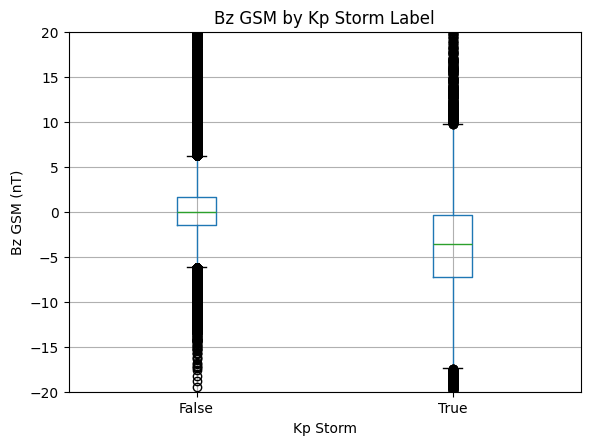

In [20]:
plt.figure(figsize=(6, 4))

kp_valid.boxplot(column="bz_gsm_nt", by="kp_storm")

plt.title("Bz GSM by Kp Storm Label")
plt.suptitle("")
plt.xlabel("Kp Storm")
plt.ylabel("Bz GSM (nT)")
plt.ylim(-20, 20)

plt.show()

### Bz GSM by Kp Storm Label

**Key takeaways**
- Storm hours: lower median `bz_gsm_nt`
- Pattern: Bz is more negative / southward during storm hours
- Full plot: many outliers
- Final plot choice: limited y-axis for readability

**EDA takeaway**
- Southward Bz is a key storm-related signal
- `bz_gsm_nt` is a strong input candidate for the first model

## Correlation Check for Priority Variables

We check correlations among selected input variables and target candidates. This is not meant to prove causation, but it helps identify which variables may contain useful predictive signal.

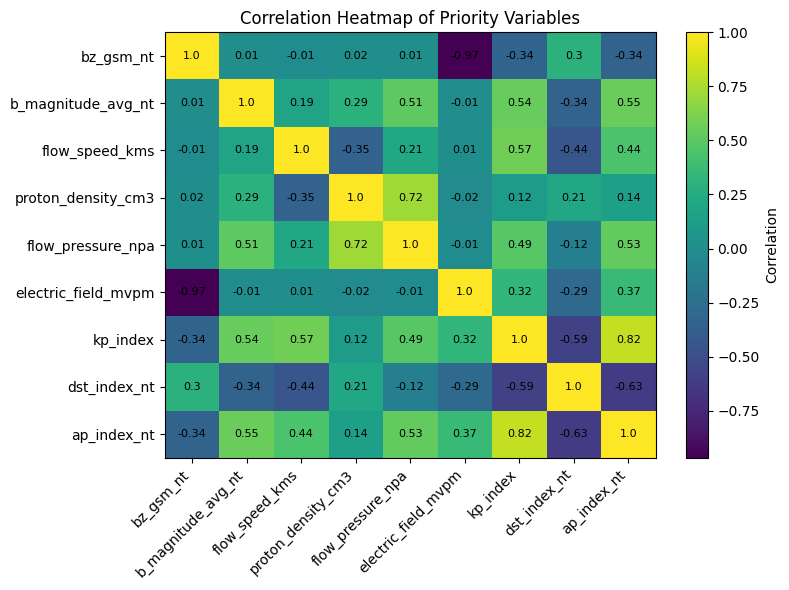

In [21]:
corr_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "kp_index",
    "dst_index_nt",
    "ap_index_nt"
]

corr_matrix = df_observed[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap of Priority Variables")

plt.tight_layout()
plt.show()

### Correlation Heatmap Observation

**Key takeaways**
- `kp_index`: positive relationship with  
  - `flow_speed_kms`
  - `b_magnitude_avg_nt`
  - `flow_pressure_npa`
  - `electric_field_mvpm`
- `dst_index_nt`: negative relationship with  
  - `flow_speed_kms`
  - `b_magnitude_avg_nt`
  - `electric_field_mvpm`
- Dst interpretation:
  - lower Dst = stronger storm disturbance
  - negative correlation can still mean stronger storm signal
- `kp_index` and `ap_index_nt`: highly correlated
- `bz_gsm_nt` and `electric_field_mvpm`: strongly overlapping signal

**EDA takeaway**
- Priority solar wind / IMF variables show storm-related signal
- Do not use geomagnetic indices as inputs if one of them is the target
- Derived variables may help, but can overlap with raw variables

## Summary Statistics for Priority Input Variables

We check basic summary statistics for selected input variables to understand their ranges and possible extreme values.

In [22]:
selected_input_cols = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm"
]

df_observed[selected_input_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bz_gsm_nt,431895.0,-0.019617,3.151968,-57.80,-1.60,0.0,1.50,58.90
b_magnitude_avg_nt,431921.0,6.181991,3.181405,0.40,4.20,5.5,7.30,68.90
flow_speed_kms,427717.0,434.178034,102.063856,156.00,358.00,411.0,490.00,1189.00
proton_density_cm3,411396.0,6.644431,5.395433,0.00,3.30,5.1,8.20,137.20
flow_pressure_npa,411388.0,2.238252,1.872459,0.00,1.22,1.8,2.67,76.06
electric_field_mvpm,403972.0,0.012465,1.464983,-63.26,-0.64,-0.0,0.67,47.11


### Summary Statistics Observation

**Key takeaways**
- Most priority variables: normal median values, but extreme min/max values
- Centered near 0:
  - `bz_gsm_nt`
  - `electric_field_mvpm`
- High-end spikes:
  - `flow_speed_kms`
  - `proton_density_cm3`
  - `flow_pressure_npa`

**EDA takeaway**
- Extreme values may be real storm-related signals
- Do not automatically remove outliers
- Inspect extreme values before deciding outlier handling for modeling

In [23]:
outlier_summary = []

for col in selected_input_cols:
    series = df_observed[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_percent = outlier_count / len(series) * 100
    
    outlier_summary.append({
        "column": col,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_percent, 2),
        "min": round(series.min(), 2),
        "max": round(series.max(), 2)
    })

pd.DataFrame(outlier_summary)

,column,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
0,bz_gsm_nt,-6.25,6.15,22354,5.18,-57.80,58.90
1,b_magnitude_avg_nt,-0.45,11.95,21337,4.94,0.40,68.90
2,flow_speed_kms,160.00,688.00,8920,2.09,156.00,1189.00
3,proton_density_cm3,-4.05,15.55,24212,5.89,0.00,137.20
4,flow_pressure_npa,-0.95,4.84,23813,5.79,0.00,76.06
5,electric_field_mvpm,-2.60,2.64,23047,5.71,-63.26,47.11


### Outlier Summary Observation

**Key takeaways**
- IQR outliers found in all priority input variables
- Most outlier rates: about 2–6%
- Extreme values appear in:
  - `bz_gsm_nt`
  - `flow_speed_kms`
  - `proton_density_cm3`
  - `flow_pressure_npa`
  - `electric_field_mvpm`

**EDA takeaway**
- Outliers may be real storm-related events
- Do not remove outliers during initial EDA
- Decide outlier handling later based on modeling goal

## Final EDA Summary

**Main findings**
- The OMNI dataset provides a long hourly time series from 1963-01-01 to 2026-06-10 for observed measurements.
- The dataset includes both potential predictor variables and geomagnetic target candidates.
- Future placeholder rows were removed before the main EDA.
- Target candidates such as `kp_index`, `dst_index_nt`, and `ap_index_nt` have strong coverage.
- Key IMF and solar wind variables have some missingness but remain usable for a first modeling pass.
- Energetic particle variables have much higher missingness and may be lower priority for the initial model.

**Target candidate findings**
- `kp_index >= 50` creates a Kp-based storm label with about 4.15% storm hours.
- `dst_index_nt <= -50` creates a Dst-based storm label with about 5.54% storm hours.
- Both target definitions show that geomagnetic storm prediction is an imbalanced classification problem.

**Feature signal findings**
- Storm hours have more negative `bz_gsm_nt`, stronger magnetic field values, faster solar wind speed, higher proton density, higher dynamic pressure, and higher electric field values.
- Correlation patterns suggest that selected IMF and solar wind variables contain useful signal for storm prediction.
- Derived variables such as `electric_field_mvpm` may be useful but may overlap with raw variables like `bz_gsm_nt` and `flow_speed_kms`.

**Modeling implications**
- A first model could use `kp_index >= 50` as a binary storm classification target.
- Candidate input features include `bz_gsm_nt`, `b_magnitude_avg_nt`, `flow_speed_kms`, `proton_density_cm3`, `flow_pressure_npa`, and `electric_field_mvpm`.
- Geomagnetic indices should not be used as input features when one of them is the target.
- Evaluation should include recall, precision, and F1-score instead of accuracy alone because storm hours are rare.

## Secondary EDA 

In [24]:
measurement_cols = [col for col in df.columns if col != "datetime"]

df["measurement_non_null_count"] = df[measurement_cols].notna().sum(axis=1)

print("Full dataset shape:", df.shape)
print("Rows with no measurements:", (df["measurement_non_null_count"] == 0).sum())
print("Rows with at least one measurement:", (df["measurement_non_null_count"] > 0).sum())

print("Full date range:")
print(df["datetime"].min(), "to", df["datetime"].max())

print("Observed date range:")
print(
    df.loc[df["measurement_non_null_count"] > 0, "datetime"].min(),
    "to",
    df.loc[df["measurement_non_null_count"] > 0, "datetime"].max()
)

df_observed = df[df["measurement_non_null_count"] > 0].copy()

Full dataset shape: (561024, 50)
Rows with no measurements: 0
Rows with at least one measurement: 561024
Full date range:
1963-01-01 00:00:00 to 2026-12-31 23:00:00
Observed date range:
1963-01-01 00:00:00 to 2026-12-31 23:00:00


In [25]:
import pandas as pd
import numpy as np
from datasets import load_dataset

ds = load_dataset("juliensimon/omni-solar-wind-parameters", split="train")
raw_df = ds.to_pandas()

print(raw_df.shape)
raw_df.head()

(561024, 48)


,datetime,bartels_rotation_number,b_magnitude_avg_nt,b_magnitude_vector_nt,b_lat_angle_gse_deg,b_lon_angle_gse_deg,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,...,proton_flux_gt4mev,proton_flux_gt10mev,proton_flux_gt30mev,proton_flux_gt60mev,ap_index_nt,f107_index_sfu,pc_n_index,al_index_nt,au_index_nt,magnetosonic_mach_number
0,1963-01-01 00:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
1,1963-01-01 01:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
2,1963-01-01 02:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
3,1963-01-01 03:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN
4,1963-01-01 04:00:00,1771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN


In [26]:
# 2. Define true measurement columns
# Only exclude datetime. At this point raw_df should not have helper columns.
true_measurement_cols = [col for col in raw_df.columns if col != "datetime"]

# 3. Count non-null measurements per row
measurement_non_null_count = raw_df[true_measurement_cols].notna().sum(axis=1)

# 4. Validate placeholder rows
print("Rows with no true measurements:", (measurement_non_null_count == 0).sum())
print("Rows with at least one true measurement:", (measurement_non_null_count > 0).sum())

print("Full date range:")
print(raw_df["datetime"].min(), "to", raw_df["datetime"].max())

print("Observed date range:")
print(
    raw_df.loc[measurement_non_null_count > 0, "datetime"].min(),
    "to",
    raw_df.loc[measurement_non_null_count > 0, "datetime"].max()
)

# 5. Create observed-only dataframe
df_observed = raw_df.loc[measurement_non_null_count > 0].copy()

print("df_observed shape:", df_observed.shape)
print("df_observed date range:")
print(df_observed["datetime"].min(), "to", df_observed["datetime"].max())

Rows with no true measurements: 4908
Rows with at least one true measurement: 556116
Full date range:
1963-01-01 00:00:00 to 2026-12-31 23:00:00
Observed date range:
1963-01-01 00:00:00 to 2026-06-10 11:00:00
df_observed shape: (556116, 48)
df_observed date range:
1963-01-01 00:00:00 to 2026-06-10 11:00:00


## Step 2: Classify OMNI Columns by Modeling Role

In [27]:
# Step 2: Classify OMNI columns by modeling role

time_cols = [
    "datetime"
]

geomagnetic_index_cols = [
    "kp_index",
    "dst_index_nt",
    "ap_index_nt",
    "ae_index_nt",
    "al_index_nt",
    "au_index_nt",
    "pc_n_index"
]

imf_cols = [
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "b_lat_angle_gse_deg",
    "b_lon_angle_gse_deg",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt"
]

solar_wind_cols = [
    "proton_temperature_k",
    "proton_density_cm3",
    "flow_speed_kms",
    "flow_lon_angle_deg",
    "flow_lat_angle_deg",
    "alpha_proton_ratio",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]

solar_context_cols = [
    "sunspot_number",
    "f107_index_sfu",
    "bartels_rotation_number"
]

particle_flux_cols = [
    "proton_flux_gt1mev",
    "proton_flux_gt2mev",
    "proton_flux_gt4mev",
    "proton_flux_gt10mev",
    "proton_flux_gt30mev",
    "proton_flux_gt60mev"
]

sigma_uncertainty_cols = [
    col for col in df_observed.columns
    if col.startswith("sigma_")
]

role_groups = {
    "time / merge key": time_cols,
    "geomagnetic index / target or leakage": geomagnetic_index_cols,
    "IMF magnetic field predictor candidate": imf_cols,
    "solar wind plasma predictor candidate": solar_wind_cols,
    "solar context optional predictor": solar_context_cols,
    "energetic particle optional predictor": particle_flux_cols,
    "measurement variability / sigma optional": sigma_uncertainty_cols
}

role_rows = []

for role, cols in role_groups.items():
    for col in cols:
        if col in df_observed.columns:
            role_rows.append({
                "column": col,
                "role": role,
                "missing_percent": round(df_observed[col].isna().mean() * 100, 2),
                "non_missing_count": df_observed[col].notna().sum(),
                "unique_count": df_observed[col].nunique()
            })

role_table = pd.DataFrame(role_rows).sort_values(["role", "missing_percent"])

role_table

,column,role,missing_percent,non_missing_count,unique_count
8,b_magnitude_avg_nt,IMF magnetic field predictor candidate,22.33,431921,453
9,b_magnitude_vector_nt,IMF magnetic field predictor candidate,22.33,431921,446
10,b_lat_angle_gse_deg,IMF magnetic field predictor candidate,22.33,431921,1790
11,b_lon_angle_gse_deg,IMF magnetic field predictor candidate,22.33,431921,3602
12,bx_gse_nt,IMF magnetic field predictor candidate,22.33,431921,498
13,by_gse_nt,IMF magnetic field predictor candidate,22.33,431921,607
14,bz_gse_nt,IMF magnetic field predictor candidate,22.33,431921,588
15,by_gsm_nt,IMF magnetic field predictor candidate,22.34,431895,591
16,bz_gsm_nt,IMF magnetic field predictor candidate,22.34,431895,594
34,proton_flux_gt10mev,energetic particle optional predictor,34.36,365015,5756


### note
- imf magnetic / solar wind plasma 
- solar context / energetic particle / sigma 



In [28]:
df_observed = df_observed.copy()
df_observed["year"] = df_observed["datetime"].dt.year

coverage_check_cols = [
    # target/reference
    "kp_index",
    
    # IMF candidates
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt",
    
    # solar wind candidates
    "flow_speed_kms",
    "proton_density_cm3",
    "proton_temperature_k",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number",
    
    # optional context
    "sunspot_number",
    "f107_index_sfu"
]

yearly_coverage = (
    df_observed
    .groupby("year")[coverage_check_cols]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

yearly_coverage

,kp_index,b_magnitude_avg_nt,b_magnitude_vector_nt,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,bz_gsm_nt,flow_speed_kms,proton_density_cm3,proton_temperature_k,flow_pressure_npa,electric_field_mvpm,plasma_beta,alfven_mach_number,magnetosonic_mach_number,sunspot_number,f107_index_sfu
year,,,,,,,,,,,,,,,,,,
1963,100.00,7.21,7.21,7.21,7.21,7.21,7.21,7.21,7.98,7.98,0.00,7.98,7.20,0.00,7.20,0.00,100.00,99.18
1964,100.00,6.64,6.64,6.64,6.64,6.64,6.64,6.64,24.18,8.95,0.00,8.95,6.64,0.00,6.64,0.00,100.00,99.73
1965,100.00,39.76,39.76,39.76,39.76,39.76,39.76,39.76,42.95,22.02,22.02,22.02,18.34,16.36,16.36,16.36,100.00,100.00
1966,100.00,43.45,43.45,43.45,43.45,43.45,43.45,43.45,34.03,34.03,34.03,34.03,14.63,14.63,14.63,14.63,100.00,99.45
1967,100.00,77.89,77.89,77.89,77.89,77.89,77.89,77.89,80.38,72.72,72.72,72.72,68.60,66.05,66.05,66.05,100.00,99.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.58,99.58,99.54,99.58,99.58,99.54,99.58,99.54,100.00,100.00
2023,100.00,99.45,99.45,99.45,99.45,99.45,99.45,99.45,97.82,97.82,97.72,97.82,97.64,97.53,97.64,97.53,100.00,100.00
2024,100.00,99.64,99.64,99.64,99.64,99.64,99.64,99.64,97.69,97.69,97.60,97.69,97.56,97.47,97.56,97.47,100.00,100.00


In [29]:
yearly_coverage.head(15)

,kp_index,b_magnitude_avg_nt,b_magnitude_vector_nt,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,bz_gsm_nt,flow_speed_kms,proton_density_cm3,proton_temperature_k,flow_pressure_npa,electric_field_mvpm,plasma_beta,alfven_mach_number,magnetosonic_mach_number,sunspot_number,f107_index_sfu
year,,,,,,,,,,,,,,,,,,
1963,100.0,7.21,7.21,7.21,7.21,7.21,7.21,7.21,7.98,7.98,0.00,7.98,7.20,0.00,7.20,0.00,100.0,99.18
1964,100.0,6.64,6.64,6.64,6.64,6.64,6.64,6.64,24.18,8.95,0.00,8.95,6.64,0.00,6.64,0.00,100.0,99.73
1965,100.0,39.76,39.76,39.76,39.76,39.76,39.76,39.76,42.95,22.02,22.02,22.02,18.34,16.36,16.36,16.36,100.0,100.00
1966,100.0,43.45,43.45,43.45,43.45,43.45,43.45,43.45,34.03,34.03,34.03,34.03,14.63,14.63,14.63,14.63,100.0,99.45
1967,100.0,77.89,77.89,77.89,77.89,77.89,77.89,77.89,80.38,72.72,72.72,72.72,68.60,66.05,66.05,66.05,100.0,99.73
1968,100.0,89.17,89.17,89.17,89.17,89.17,89.17,89.17,62.55,50.92,46.31,50.92,57.91,43.81,48.33,43.81,100.0,100.00
1969,100.0,69.42,69.42,69.42,69.42,69.42,69.42,69.42,69.29,55.06,35.38,55.06,52.74,26.68,44.22,26.68,100.0,100.00
1970,100.0,56.86,56.86,56.86,56.86,56.86,56.86,56.86,61.42,21.02,9.45,21.02,40.86,5.82,16.22,5.82,100.0,100.00
1971,100.0,62.43,62.43,62.43,62.43,62.43,62.43,62.43,39.73,32.60,32.60,32.60,28.66,25.65,25.65,25.65,100.0,100.00


In [30]:
yearly_coverage.tail(15)

,kp_index,b_magnitude_avg_nt,b_magnitude_vector_nt,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,bz_gsm_nt,flow_speed_kms,proton_density_cm3,proton_temperature_k,flow_pressure_npa,electric_field_mvpm,plasma_beta,alfven_mach_number,magnetosonic_mach_number,sunspot_number,f107_index_sfu
year,,,,,,,,,,,,,,,,,,
2012,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.95,99.04,99.50,99.04,99.95,99.03,99.04,99.03,100.00,99.73
2013,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.91,99.97,99.91,100.00,99.91,99.91,99.91,100.00,100.00
2014,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,97.02,99.91,97.02,100.00,97.00,97.02,97.00,100.00,100.00
2015,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.66,99.92,99.61,100.00,99.55,99.61,99.58,100.00,99.73
2016,100.00,99.99,99.99,99.99,99.99,99.99,99.99,99.99,100.00,99.74,99.95,99.74,100.00,99.69,99.74,99.68,100.00,100.00
2017,100.00,99.93,99.93,99.93,99.93,99.93,99.63,99.63,99.93,99.89,99.86,99.89,99.63,99.82,99.89,99.82,100.00,100.00
2018,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.98,100.00,99.93,100.00,99.93,99.93,99.98,100.00,100.00
2019,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.37,99.97,99.37,100.00,99.35,99.37,99.35,100.00,100.00
2020,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,99.99,99.94,99.98,99.94,99.99,99.93,99.94,99.93,100.00,100.00


In [31]:
# Summarize yearly coverage across candidate predictor columns

predictor_candidate_cols = [
    # IMF / magnetic field candidates
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt",
    
    # solar wind candidates
    "flow_speed_kms",
    "proton_density_cm3",
    "proton_temperature_k",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]

yearly_coverage = (
    df_observed
    .assign(year=df_observed["datetime"].dt.year)
    .groupby("year")[predictor_candidate_cols]
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

coverage_summary_by_year = pd.DataFrame({
    "min_candidate_coverage": yearly_coverage.min(axis=1),
    "median_candidate_coverage": yearly_coverage.median(axis=1),
    "max_candidate_coverage": yearly_coverage.max(axis=1),
    "num_features_above_80": (yearly_coverage >= 80).sum(axis=1),
    "num_features_above_90": (yearly_coverage >= 90).sum(axis=1),
    "num_features_above_95": (yearly_coverage >= 95).sum(axis=1),
})


In [32]:
pd.set_option("display.max_rows", 100)
coverage_summary_by_year

,min_candidate_coverage,median_candidate_coverage,max_candidate_coverage,num_features_above_80,num_features_above_90,num_features_above_95
year,,,,,,
1963,0.00,7.21,7.98,0,0,0
1964,0.00,6.64,24.18,0,0,0
1965,16.36,39.76,42.95,0,0,0
1966,14.63,34.03,43.45,0,0,0
1967,66.05,77.89,80.38,1,0,0
1968,43.81,62.55,89.17,7,0,0
1969,26.68,69.29,69.42,0,0,0
1970,5.82,56.86,61.42,0,0,0
1971,25.65,39.73,62.43,0,0,0


In [33]:
coverage_summary_by_year[
    coverage_summary_by_year["num_features_above_90"] >= 10
].head(20)

,min_candidate_coverage,median_candidate_coverage,max_candidate_coverage,num_features_above_80,num_features_above_90,num_features_above_95
year,,,,,,
1979,90.37,91.11,96.83,15,15,7
1980,49.34,92.10,94.30,12,12,0
1981,34.55,91.04,92.82,12,12,0
1995,98.42,98.53,98.58,15,15,15
1996,98.20,98.30,98.62,15,15,15
1997,98.50,98.56,98.60,15,15,15
1998,96.96,99.62,99.98,15,15,15
1999,96.52,99.67,99.73,15,15,15
2000,91.27,99.98,100.00,15,15,9


In [34]:
coverage_summary_by_year[
    coverage_summary_by_year["num_features_above_80"] >= 10
].head(20)

,min_candidate_coverage,median_candidate_coverage,max_candidate_coverage,num_features_above_80,num_features_above_90,num_features_above_95
year,,,,,,
1974,79.62,81.74,93.95,11,4,0
1979,90.37,91.11,96.83,15,15,7
1980,49.34,92.10,94.30,12,12,0
1981,34.55,91.04,92.82,12,12,0
1995,98.42,98.53,98.58,15,15,15
1996,98.20,98.30,98.62,15,15,15
1997,98.50,98.56,98.60,15,15,15
1998,96.96,99.62,99.98,15,15,15
1999,96.52,99.67,99.73,15,15,15


In [35]:
df_model_period = df_observed[df_observed["datetime"] >= "1995-01-01"].copy()

print(df_model_period.shape)
print(df_model_period["datetime"].min(), "to", df_model_period["datetime"].max())

(275604, 49)
1995-01-01 00:00:00 to 2026-06-10 11:00:00


### note

for candidate_pool, selected features included 
- IMF + solar wind plasma/derived variables centered non-leaky predictors

1. IMF / magnetic field predictor candidates
    -   shows interplanetary magnetic field condition around the Earth
2. Solar wind plasma predictor candidates
    -   shows solar wind speed, density, temp, pressure, derived plasma condition

* excluded: geomagnetic indices - target/leakage candidates
* excluded/optional: solar context optional - non near-Earth solar wind feature
* excluded/optional: energetic particle flux - high missingness
* excluded: sigma columns 

In [36]:
candidate_pool = [
    "b_magnitude_avg_nt",
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "bz_gsm_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "proton_temperature_k",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]

candidate_missing_model_period = pd.DataFrame({
    "missing_percent": (df_model_period[candidate_pool].isna().mean() * 100).round(2),
    "non_missing_count": df_model_period[candidate_pool].notna().sum()
}).sort_values("missing_percent")

candidate_missing_model_period

,missing_percent,non_missing_count
b_magnitude_avg_nt,0.41,274480
b_magnitude_vector_nt,0.41,274480
bx_gse_nt,0.41,274480
by_gse_nt,0.41,274480
bz_gse_nt,0.41,274480
by_gsm_nt,0.42,274454
bz_gsm_nt,0.42,274454
flow_speed_kms,0.54,274106
electric_field_mvpm,0.66,273788
proton_temperature_k,2.04,269970


After restricting the OMNI data to 1995 onward, missingness in the main IMF and solar wind candidate predictors becomes very low. Most magnetic field and solar wind speed variables have less than 1% missingness, while plasma-derived variables such as density, pressure, beta, and Mach numbers have around 2–2.4% missingness. This supports using 1995 onward as the main model/merge period.

In [ ]:
# as kp_index >= 50 indicates storm
# so if kp >= 5.0 storm yes, kp < 5.0 storm no.

df_model_period = df_model_period[df_model_period["kp_index"].notna()].copy()

df_model_period["kp_storm"] = df_model_period["kp_index"] >= 50

df_model_period["kp_storm"].value_counts()

kp_storm
False    267927
True       7665
Name: count, dtype: int64

In [ ]:
round(df_model_period["kp_storm"].mean() * 100, 2)
# due to high imbalance as expected, later focus on recall, precision, F1-score, PR-AUC, confusion matrix

np.float64(2.78)

In [39]:
median_compare = df_model_period.groupby("kp_storm")[candidate_pool].median().T

median_compare.columns = ["non_storm_median", "storm_median"]
median_compare["difference"] = median_compare["storm_median"] - median_compare["non_storm_median"]

median_compare

,non_storm_median,storm_median,difference
b_magnitude_avg_nt,5.10,11.50,6.40
b_magnitude_vector_nt,4.50,9.80,5.30
bx_gse_nt,0.00,-0.20,-0.20
by_gse_nt,-0.10,0.80,0.90
bz_gse_nt,0.00,-2.90,-2.90
by_gsm_nt,-0.10,0.80,0.90
bz_gsm_nt,-0.00,-4.00,-4.00
flow_speed_kms,403.00,543.00,140.00
proton_density_cm3,4.80,6.90,2.10
proton_temperature_k,66903.50,175913.50,109010.00


## WHEN STORM, SEEMS LIKE

-   b_magnitude_avg_nt (hourly average of |B|) --> magnetic field stronger
    -   b_magnitude_vector_nt omitted because of duplicated usage (magnitude of hourly-averaged vector)

-   bz_gsm_nt --> Bz more negative/southward 
    -   bz_gsme_nt omitted because GSM coordinates are more directly tied to Earth's magnetosphere. Negative/southward Bz in GSM is commonly interpreted as geoeffective for magnetic reconnection.

-   flow_speed_kms (solar wind speed) --> solar wind faster

-   proton_density_cm3 (how many particles) --> high density

-   flow_pressure_npa (combined pressure effect from densi) --> pressure higher

### Optional
-   electric_field_mvpm	--> electirc field higher (V x Bz) (derived feature optional)
-   proton_temperature_k --> temperature higher
- alven/magnotosonic mach ignored?

In [40]:
corr = df_model_period[candidate_pool].corr()

corr

,b_magnitude_avg_nt,b_magnitude_vector_nt,bx_gse_nt,by_gse_nt,bz_gse_nt,by_gsm_nt,bz_gsm_nt,flow_speed_kms,proton_density_cm3,proton_temperature_k,flow_pressure_npa,electric_field_mvpm,plasma_beta,alfven_mach_number,magnetosonic_mach_number
b_magnitude_avg_nt,1.000000,0.964085,-0.006363,0.029670,-0.000975,0.025061,-0.011755,0.198267,0.280243,0.315057,0.522192,0.009423,-0.321478,-0.556189,-0.622258
b_magnitude_vector_nt,0.964085,1.000000,-0.004539,0.029262,0.001795,0.024161,-0.008696,0.130917,0.233821,0.216387,0.420542,0.005268,-0.321847,-0.568581,-0.650326
bx_gse_nt,-0.006363,-0.004539,1.000000,-0.442583,0.004704,-0.435927,-0.003078,-0.017122,0.006841,-0.009621,-0.002709,0.006604,-0.002153,-0.006676,-0.011883
by_gse_nt,0.029670,0.029262,-0.442583,1.000000,0.003701,0.970537,-0.001048,0.025762,-0.006887,0.013696,0.011648,-0.000075,-0.002685,-0.006009,-0.008562
bz_gse_nt,-0.000975,0.001795,0.004704,0.003701,1.000000,0.012561,0.913486,-0.000566,0.001832,0.004338,-0.002565,-0.880601,-0.003189,-0.007703,-0.010976
by_gsm_nt,0.025061,0.024161,-0.435927,0.970537,0.012561,1.000000,0.006487,0.026594,-0.007127,0.014466,0.013148,-0.005651,-0.002110,-0.004407,-0.005610
bz_gsm_nt,-0.011755,-0.008696,-0.003078,-0.001048,0.913486,0.006487,1.000000,-0.013862,0.007104,-0.005117,-0.005411,-0.963443,0.002011,0.000063,-0.004645
flow_speed_kms,0.198267,0.130917,-0.017122,0.025762,-0.000566,0.026594,-0.013862,1.000000,-0.360969,0.658258,0.205625,0.017346,-0.224444,-0.141035,0.246353
proton_density_cm3,0.280243,0.233821,0.006841,-0.006887,0.001832,-0.007127,0.007104,-0.360969,1.000000,-0.161054,0.707781,-0.008099,0.266634,0.275639,0.035546
proton_temperature_k,0.315057,0.216387,-0.009621,0.013696,0.004338,0.014466,-0.005117,0.658258,-0.161054,1.000000,0.281418,0.012930,-0.157890,-0.196404,-0.100499


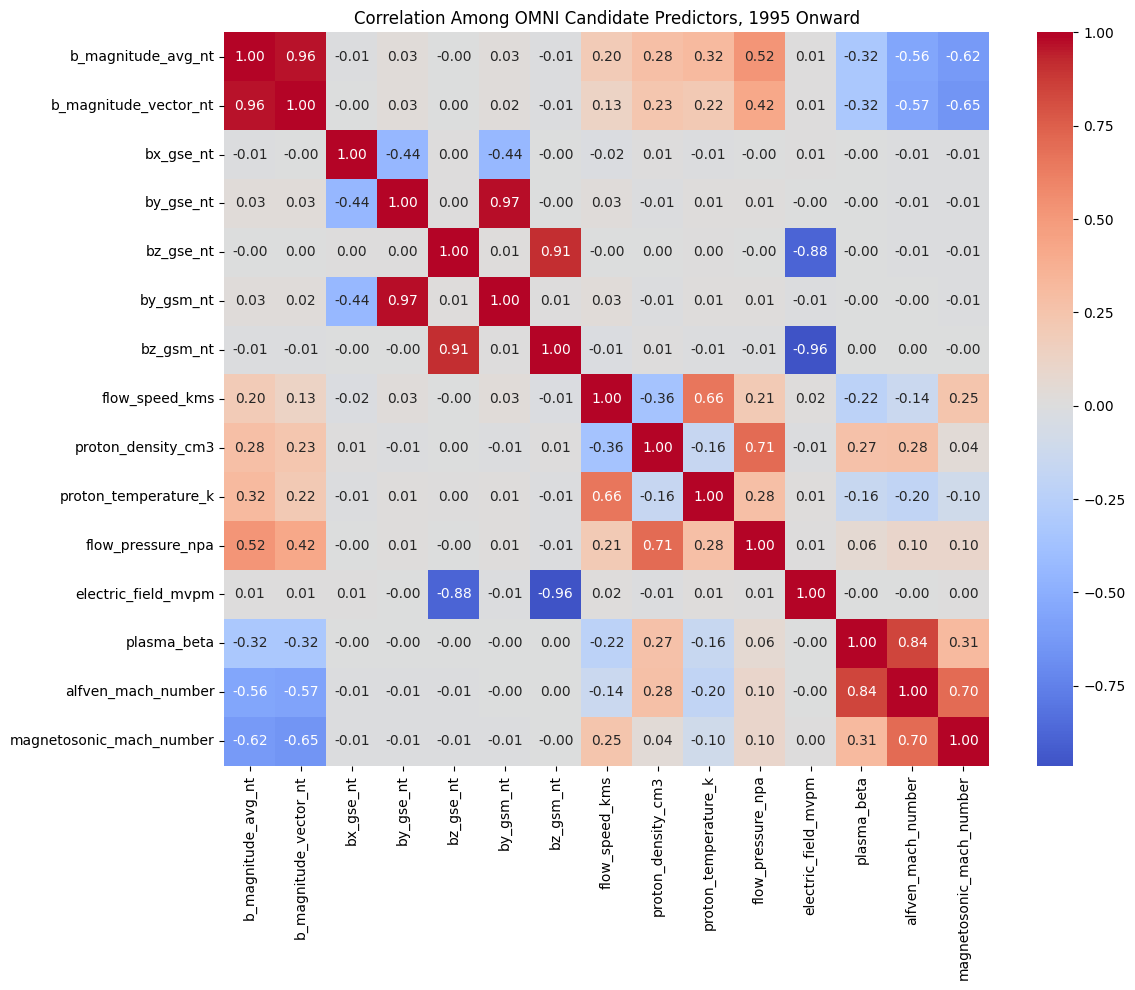

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Among OMNI Candidate Predictors, 1995 Onward")
plt.tight_layout()
plt.show()

In [42]:
# Find highly correlated feature pairs

corr_abs = corr.abs()

high_corr_pairs = []

for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        col1 = corr_abs.columns[i]
        col2 = corr_abs.columns[j]
        corr_value = corr.loc[col1, col2]
        abs_corr_value = corr_abs.loc[col1, col2]
        
        if abs_corr_value >= 0.85:
            high_corr_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "correlation": round(corr_value, 3),
                "abs_correlation": round(abs_corr_value, 3)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values(
    "abs_correlation", ascending=False
)

high_corr_pairs_df

,feature_1,feature_2,correlation,abs_correlation
1,by_gse_nt,by_gsm_nt,0.971,0.971
0,b_magnitude_avg_nt,b_magnitude_vector_nt,0.964,0.964
4,bz_gsm_nt,electric_field_mvpm,-0.963,0.963
2,bz_gse_nt,bz_gsm_nt,0.913,0.913
3,bz_gse_nt,electric_field_mvpm,-0.881,0.881


## Final Decision for Keep / Drop / Optional

In [44]:
feature_decision = pd.DataFrame([
    {
        "feature": "bz_gsm_nt",
        "decision": "Strong keep",
        "reason": "Southward Bz in GSM is physically central to geomagnetic storm coupling; storm median is much more negative."
    },
    {
        "feature": "b_magnitude_avg_nt",
        "decision": "Strong keep",
        "reason": "Represents overall IMF strength; storm median is much higher. Kept instead of b_magnitude_vector_nt due to high redundancy."
    },
    {
        "feature": "flow_speed_kms",
        "decision": "Strong keep",
        "reason": "Solar wind is much faster during storm hours and is a core solar wind driver."
    },
    {
        "feature": "proton_density_cm3",
        "decision": "Strong keep",
        "reason": "Storm hours show higher proton density; density contributes to solar wind pressure."
    },
    {
        "feature": "flow_pressure_npa",
        "decision": "Strong keep",
        "reason": "Dynamic pressure is higher during storm hours and represents magnetosphere compression effects."
    },
    {
        "feature": "electric_field_mvpm",
        "decision": "Optional",
        "reason": "Strong storm signal, but highly correlated with Bz GSM because it is a derived coupling-related feature."
    },
    {
        "feature": "proton_temperature_k",
        "decision": "Optional",
        "reason": "Storm median is much higher, but it is secondary compared with Bz, speed, density, and pressure."
    },
    {
        "feature": "b_magnitude_vector_nt",
        "decision": "Drop first model",
        "reason": "Highly correlated with b_magnitude_avg_nt; keep only one magnetic magnitude feature."
    },
    {
        "feature": "bz_gse_nt",
        "decision": "Drop first model",
        "reason": "Highly correlated with bz_gsm_nt; GSM Bz is preferred for magnetospheric coupling interpretation."
    },
    {
        "feature": "by_gse_nt / by_gsm_nt",
        "decision": "Drop first model",
        "reason": "Highly redundant with each other and less central than Bz for first storm prediction model."
    },
    {
        "feature": "bx_gse_nt",
        "decision": "Drop first model",
        "reason": "Small storm/non-storm median difference and less directly tied to storm mechanism."
    },
    {
        "feature": "plasma_beta / alfven_mach_number / magnetosonic_mach_number",
        "decision": "Drop or later optional",
        "reason": "Derived/complex plasma condition features; useful for later model comparison but lower priority for first feature set."
    }
])

feature_decision

,feature,decision,reason
0,bz_gsm_nt,Strong keep,Southward Bz in GSM is physically central to g...
1,b_magnitude_avg_nt,Strong keep,Represents overall IMF strength; storm median ...
2,flow_speed_kms,Strong keep,Solar wind is much faster during storm hours a...
3,proton_density_cm3,Strong keep,Storm hours show higher proton density; densit...
4,flow_pressure_npa,Strong keep,Dynamic pressure is higher during storm hours ...
5,electric_field_mvpm,Optional,"Strong storm signal, but highly correlated wit..."
6,proton_temperature_k,Optional,"Storm median is much higher, but it is seconda..."
7,b_magnitude_vector_nt,Drop first model,Highly correlated with b_magnitude_avg_nt; kee...
8,bz_gse_nt,Drop first model,Highly correlated with bz_gsm_nt; GSM Bz is pr...
9,by_gse_nt / by_gsm_nt,Drop first model,Highly redundant with each other and less cent...


In [43]:
# Final Keeps

strong_omni_features = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa"
]

optional_omni_features = [
    "electric_field_mvpm",
    "proton_temperature_k"
]

drop_first_model = [
    "b_magnitude_vector_nt",
    "bx_gse_nt",
    "by_gse_nt",
    "bz_gse_nt",
    "by_gsm_nt",
    "plasma_beta",
    "alfven_mach_number",
    "magnetosonic_mach_number"
]


We started with a broader IMF and solar wind candidate pool, checked coverage after 1995, compared storm vs non-storm medians, and removed redundant features using correlation. Based on this, the core OMNI features are Bz GSM, IMF magnitude, solar wind speed, proton density, and flow pressure, with electric field and proton temperature as optional candidates.

In [45]:
# Final selected OMNI candidate predictors

selected_omni_features = [
    "bz_gsm_nt",
    "b_magnitude_avg_nt",
    "flow_speed_kms",
    "proton_density_cm3",
    "flow_pressure_npa",
    "electric_field_mvpm",
    "proton_temperature_k"
]

# Use 1995 onward because predictor coverage becomes stable from this period
df_model_period = df_observed[df_observed["datetime"] >= "1995-01-01"].copy()

# Keep rows with valid target source
df_model_period = df_model_period[df_model_period["kp_index"].notna()].copy()

# Create binary geomagnetic storm label
# kp_index is stored as Kp x 10, so kp_index >= 50 means Kp >= 5.0
df_model_period["kp_storm"] = df_model_period["kp_index"] >= 50

# Create cleaned candidate dataset with selected non-leaky predictors
omni_cleaned_candidates = df_model_period[
    ["datetime", "kp_storm"] + selected_omni_features
].dropna(subset=selected_omni_features).copy()

print("Cleaned OMNI candidate dataset shape:", omni_cleaned_candidates.shape)
print("Date range:", omni_cleaned_candidates["datetime"].min(), "to", omni_cleaned_candidates["datetime"].max())

print("\nStorm label balance:")
print(omni_cleaned_candidates["kp_storm"].value_counts())
print("Storm percent:", round(omni_cleaned_candidates["kp_storm"].mean() * 100, 2), "%")

omni_cleaned_candidates.head()

Cleaned OMNI candidate dataset shape: (269020, 9)
Date range: 1995-01-01 00:00:00 to 2026-05-27 01:00:00

Storm label balance:
kp_storm
False    261494
True       7526
Name: count, dtype: int64
Storm percent: 2.8 %


,datetime,kp_storm,bz_gsm_nt,b_magnitude_avg_nt,flow_speed_kms,proton_density_cm3,flow_pressure_npa,electric_field_mvpm,proton_temperature_k
280512,1995-01-01 00:00:00,False,-1.2,4.0,315.0,16.3,2.87,0.38,15816.0
280513,1995-01-01 01:00:00,False,-0.7,3.0,315.0,18.8,3.28,0.22,15601.0
280514,1995-01-01 02:00:00,False,0.0,3.2,320.0,19.3,3.46,-0.00,20703.0
280515,1995-01-01 03:00:00,False,0.7,4.3,317.0,16.4,2.90,-0.22,25094.0
280516,1995-01-01 04:00:00,False,0.5,4.8,313.0,14.5,2.51,-0.16,25604.0


### Cleaned OMNI Candidate Dataset

For the cleaned OMNI candidate dataset, I use records from 1995 onward because the selected IMF and solar wind predictor candidates have stable coverage during this period. I create a binary geomagnetic storm label, `kp_storm`, using `kp_index >= 50`, since `kp_index` is stored as Kp × 10 and Kp ≥ 5.0 indicates geomagnetic storm conditions.

To avoid target leakage, I exclude `kp_index` and other geomagnetic indices from the exported predictor dataset. I retain selected non-leaky OMNI predictors related to IMF strength, southward Bz, solar wind speed, density, pressure, interplanetary electric field, and proton temperature.

Rows with missing values in the selected predictor columns are removed using complete-case filtering. This keeps the cleaned dataset simple, reproducible, and ready for downstream modeling or merging.

In [50]:
from pathlib import Path

correct_output_path = Path("../../data/clean-data/omni-solar-wind-events.parquet")
correct_output_path.parent.mkdir(parents=True, exist_ok=True)

omni_cleaned_candidates.to_parquet(correct_output_path, index=False)

print("Saved to:", correct_output_path.resolve())
print("Exists:", correct_output_path.exists())

Saved to: /Users/kwaknakyung/projects/geomagnetic-storm-predictor/data/clean-data/omni-solar-wind-events.parquet
Exists: True
